<a href="https://colab.research.google.com/github/jdivyansh686anu/aps-lab/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [ ]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}


Now, let's implement Prim's algorithm:

In [ ]:
def prim_algorithm(graph):
    min_tree = {}
    visited = set()
    min_tree[list(graph.keys())[0]] = []
    min_weight = 0

    while len(visited) < len(graph):
        min_edge = float('inf')
        next_vertex = None
        for vertex in min_tree:
            for adj_vertex, weight in graph[vertex].items():
                if adj_vertex not in visited:
                    if weight < min_edge:
                        min_edge = weight
                        next_vertex = adj_vertex

        min_tree[next_vertex] = []
        visited.add(next_vertex)
        min_weight += min_edge

    return min_tree, min_weight

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [ ]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  {'A': [], 'B': [], 'C': [], 'D': []}
Minimum Weight:  50


Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

Kruskal MST edges (u, v, w):
(0, 3, 5)
(2, 4, 5)
(3, 5, 6)
(0, 1, 7)
(1, 4, 7)
(4, 6, 9)
Kruskal total weight: 39

Prim MST edges (u, v, w):
(0, 3, 5)
(3, 5, 6)
(0, 1, 7)
(1, 4, 7)
(4, 2, 5)
(4, 6, 9)
Prim total weight: 39


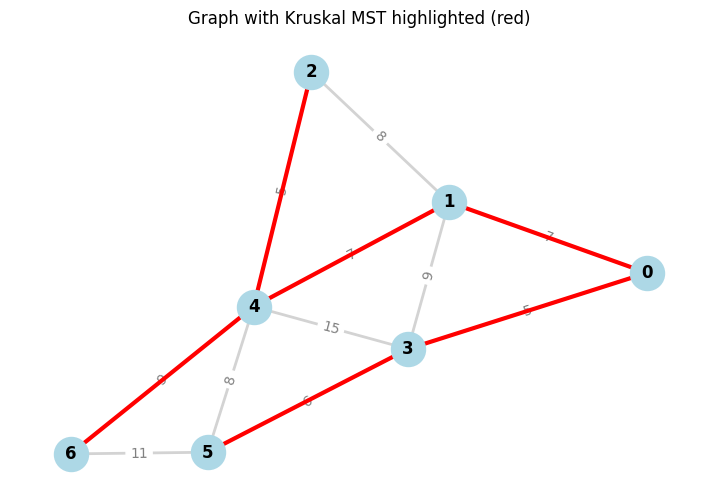

In [2]:


!pip install --quiet networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import heapq

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        elif self.rank[ry] < self.rank[rx]:
            self.parent[ry] = rx
        else:
            self.parent[ry] = rx
            self.rank[rx] += 1
        return True

def kruskal_mst(num_nodes, edges):
    """
    edges: list of tuples (u, v, w)
    nodes are 0..num_nodes-1
    returns: list of edges in MST and total weight
    """
    uf = UnionFind(num_nodes)

    edges_sorted = sorted(edges, key=lambda e: e[2])
    mst = []
    total = 0
    for u, v, w in edges_sorted:
        if uf.union(u, v):
            mst.append((u, v, w))
            total += w
            if len(mst) == num_nodes - 1:
                break
    return mst, total


def prim_mst(num_nodes, edges, start=0):
    """
    edges: list of tuples (u, v, w)
    returns: list of edges in MST and total weight
    """
    adj = [[] for _ in range(num_nodes)]
    for u, v, w in edges:
        adj[u].append((v, w))
        adj[v].append((u, w))

    visited = [False]*num_nodes
    min_heap = [(0, start, -1)]
    mst = []
    total = 0
    while min_heap:
        w, node, parent = heapq.heappop(min_heap)
        if visited[node]:
            continue
        visited[node] = True
        if parent != -1:
            mst.append((parent, node, w))
            total += w
        for nei, wt in adj[node]:
            if not visited[nei]:
                heapq.heappush(min_heap, (wt, nei, node))

    return mst, total

edges = [
    (0, 1, 7),
    (0, 3, 5),
    (1, 2, 8),
    (1, 3, 9),
    (1, 4, 7),
    (2, 4, 5),
    (3, 4, 15),
    (3, 5, 6),
    (4, 5, 8),
    (4, 6, 9),
    (5, 6, 11)
]
num_nodes = 7

kr_mst, kr_total = kruskal_mst(num_nodes, edges)
pr_mst, pr_total = prim_mst(num_nodes, edges, start=0)

print("Kruskal MST edges (u, v, w):")
for e in kr_mst:
    print(e)
print("Kruskal total weight:", kr_total)
print()
print("Prim MST edges (u, v, w):")
for e in pr_mst:
    print(e)
print("Prim total weight:", pr_total)

G = nx.Graph()
G.add_weighted_edges_from(edges)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(9,6))
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=600)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='lightgray', width=2)
edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray')

mst_edges = [(u,v) for u,v,w in kr_mst]
nx.draw_networkx_edges(G, pos, edgelist=mst_edges, edge_color='red', width=3)

plt.title("Graph with Kruskal MST highlighted (red)")
plt.axis('off')
plt.show()


MST edges (u, v, weight):
A - B : 2
B - C : 1
B - D : 4
C - E : 6
Total weight: 13


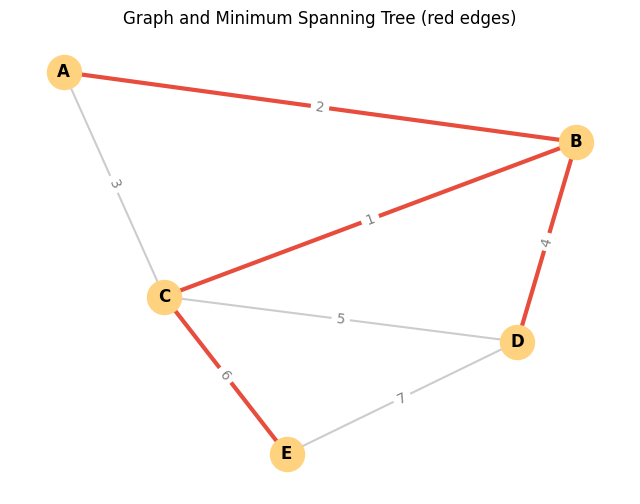

In [3]:

import heapq
import networkx as nx
import matplotlib.pyplot as plt

def prim_mst(graph, start=None):
    """
    Compute a Minimum Spanning Tree (MST) using Prim's algorithm.
    graph: dict where graph[u] is a dict {v: weight, ...}
    start: optional starting vertex (if None, pick an arbitrary one)
    Returns: list of edges in MST as (u, v, weight) and total weight
    """
    if not graph:
        return [], 0

    if start is None:
        start = next(iter(graph))

    visited = set([start])
    edges_heap = []

    for v, w in graph[start].items():
        heapq.heappush(edges_heap, (w, start, v))

    mst_edges = []
    total_weight = 0

    while edges_heap and len(visited) < len(graph):
        w, u, v = heapq.heappop(edges_heap)
        if v in visited:
            continue

        visited.add(v)
        mst_edges.append((u, v, w))
        total_weight += w

        for to, wt in graph[v].items():
            if to not in visited:
                heapq.heappush(edges_heap, (wt, v, to))

    if len(visited) != len(graph):
        raise ValueError("Graph is disconnected; MST does not exist for all vertices.")

    return mst_edges, total_weight

graph = {
    'A': {'B': 2, 'C': 3},
    'B': {'A': 2, 'C': 1, 'D': 4},
    'C': {'A': 3, 'B': 1, 'D': 5, 'E': 6},
    'D': {'B': 4, 'C': 5, 'E': 7},
    'E': {'C': 6, 'D': 7}
}

mst_edges, total = prim_mst(graph)
print("MST edges (u, v, weight):")
for u, v, w in mst_edges:
    print(f"{u} - {v} : {w}")
print("Total weight:", total)

def draw_graph_and_mst(graph, mst_edges):
    G = nx.Graph()
    for u, nbrs in graph.items():
        for v, w in nbrs.items():
            if not G.has_edge(u, v):
                G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8,6))

    nx.draw_networkx_nodes(G, pos, node_size=600, node_color="#ffd27f")
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    all_edges = list(G.edges(data=True))
    nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v,_ in all_edges],
                           edge_color="#cccccc", width=1.5)

    mst_edge_list = [(u, v) for u, v, _ in mst_edges]
    nx.draw_networkx_edges(G, pos, edgelist=mst_edge_list, edge_color="#e74c3c", width=3)

    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray')
    plt.title("Graph and Minimum Spanning Tree (red edges)")
    plt.axis('off')
    plt.show()

draw_graph_and_mst(graph, mst_edges)


Use same apporach for Kruskal's algorithm

In [ ]:
# implement Kruskal's algorithm